## 📊 Superstore Sales & Profitability Analysis

An end-to-end data analysis project exploring sales performance, profitability for a retail superstore, using Python (Pandas, NumPy, Matplotlib).

**Objective:** Identify key drivers of profitability and provide data-backed business recommendations to improve margins, regional performance, and customer retention.

## 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/samplesuperstore.csv", encoding ='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

## 2. Data Cleaning

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [10]:
df.columns = df.columns.str.replace('-', '_').str.replace(' ', '_')

In [11]:
df.columns = df.columns.str.lower()
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

## 3. Adding Columns For Further Calculation

In [12]:
df['order_month'] = df['order_date'].dt.month
df['order_year'] = df['order_date'].dt.year
df['profit_margin'] = df['profit'] / df['sales']

In [13]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,order_month,order_year,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,0.1125


In [14]:
df.to_csv('../data/superstore_cleaned.csv', index=False)

## 4. Exploratory Data Analysis

### 4.1 Sales & Profit by Category

In [15]:
df.groupby('category')[['sales','profit']].sum()

,sales,profit
category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


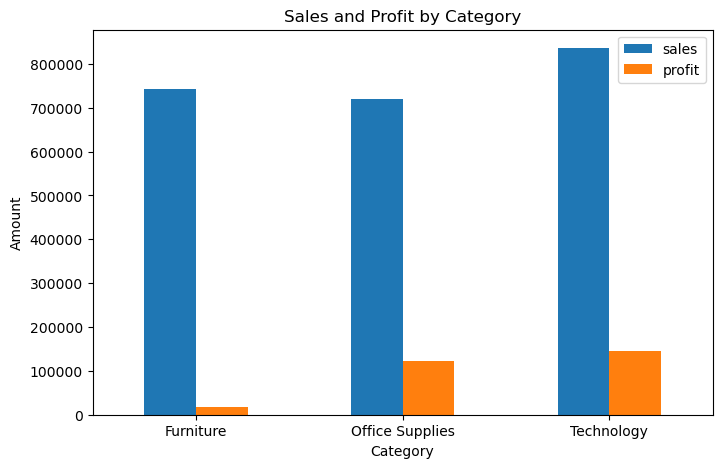

In [16]:
category_sales = df.groupby('category')[['sales','profit']].sum()

category_sales.plot(kind='bar',figsize = (8,5))
plt.title('Sales and Profit by Category')
plt.xticks(rotation = 0)
plt.xlabel('Category')
plt.ylabel('Amount')
plt.savefig('../visualization/sales_and_profit_by_category.png', dpi=200, bbox_inches='tight')
plt.show()

### 4.2 Discount Analysis by Category & Sub-Category

In [17]:
df.groupby('category')['discount'].mean()

category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: discount, dtype: float64

In [18]:
df['category'] == 'Furniture'
df.groupby('sub_category')[['sales','profit','discount']].mean()

,sales,profit,discount
sub_category,,,
Accessories,215.974604,54.111788,0.078452
Appliances,230.755710,38.922758,0.166524
Art,34.068834,8.200737,0.074874
Binders,133.560560,19.843574,0.372292
Bookcases,503.859633,-15.230509,0.211140
Chairs,532.332420,43.095894,0.170178
Copiers,2198.941618,817.909190,0.161765
Envelopes,64.867724,27.418019,0.080315
Fasteners,13.936774,4.375660,0.082028


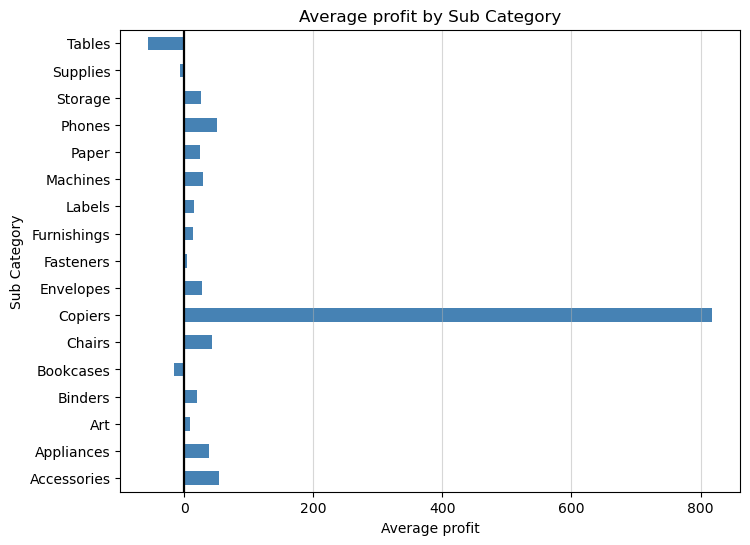

In [19]:
subcat_profit = df.groupby('sub_category')['profit'].mean()

subcat_profit.plot(kind='barh', figsize =(8,6), color = 'steelblue')
plt.title('Average profit by Sub Category')
plt.xlabel('Average profit')
plt.ylabel('Sub Category')
plt.axvline(0, color='black', linewidth=1.6)
plt.grid(axis='x',alpha = 0.5)
plt.savefig('../visualization/average_profit_by_sub_category.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
df[df['sub_category'] == 'Copiers'][['sales','profit','discount']].mean()

sales       2198.941618
profit       817.909190
discount       0.161765
dtype: float64

### 4.3 Regional Performance


In [21]:
df.groupby('region')[['sales','profit']].sum()

,sales,profit
region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [22]:
df.groupby('region')['discount'].mean()

region
Central    0.240353
East       0.145365
South      0.147253
West       0.109335
Name: discount, dtype: float64

In [23]:
region_summary = df.groupby('region')[['sales', 'profit']].sum()
region_summary['profit_margin'] = region_summary['profit'] / region_summary['sales'] * 100
region_summary

,sales,profit,profit_margin
region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


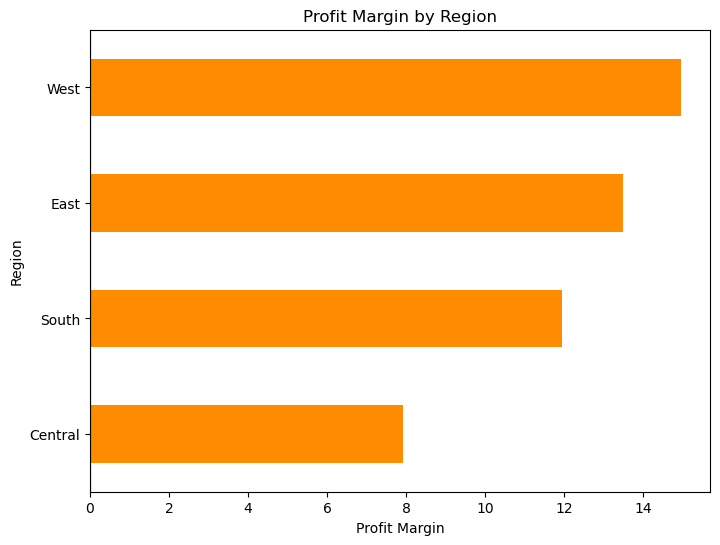

In [24]:
region_summary['profit_margin'].sort_values().plot(kind='barh',figsize = (8,6),color = 'darkorange')
plt.title('Profit Margin by Region')
plt.xlabel('Profit Margin')
plt.ylabel('Region')
plt.axvline(0,color='black',linewidth=0.8)
plt.savefig('../visualization/profit_margin_by_region.png', dpi=200, bbox_inches='tight')
plt.show()

### 4.4 Discount vs. Profit Relationship

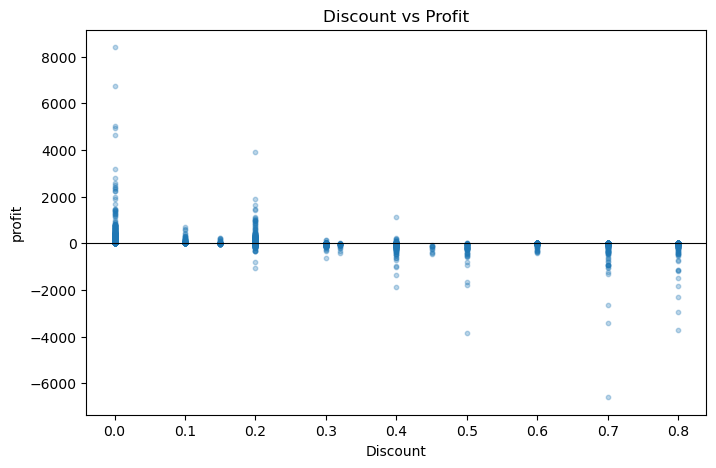

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(df['discount'],df['profit'], alpha = 0.3, s= 10)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('profit')
plt.axhline(0, color='black', linewidth=0.8)
plt.savefig('../visualization/discount_vs_profit.png', dpi=200, bbox_inches='tight')
plt.show()

### 4.5 Sales Trends Over Time


In [26]:
df.groupby('order_year')['sales'].sum()

order_year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: sales, dtype: float64

In [27]:
df.groupby('order_month')['sales'].sum()

order_month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: sales, dtype: float64

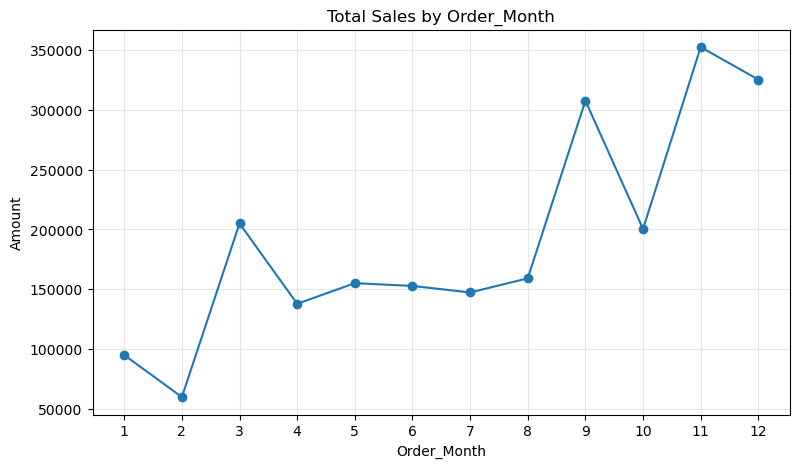

In [28]:
monthly_sales = df.groupby('order_month')['sales'].sum()
monthly_sales.plot(kind='line', marker='o', figsize = (9,5))
plt.xlabel('Order_Month')
plt.ylabel('Amount')
plt.title('Total Sales by Order_Month')
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.savefig('../visualization/total_sales_by_order_month.png', dpi=200, bbox_inches='tight')
plt.show()

### 4.6 Top Customer Analysis


In [29]:
top10cust = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

In [30]:
perc_of_top10cust = (top10cust.sum() / df['sales'].sum())*100
perc_of_top10cust

np.float64(6.6955907799857455)

In [31]:
df['customer_name'].nunique()

793

## 📊 Business Insights

Based on the exploratory analysis above, the following key insights emerged:

**1. Discounting is the primary driver of profit loss.**
Orders with discounts above 30% are overwhelmingly unprofitable, with losses intensifying sharply beyond 50%. This single factor explains much of the profitability problems found elsewhere in the business.

**2. Furniture is the weakest-performing category.**
Despite generating comparable revenue to Technology (~$742K), Furniture converts only ~2.5% of that into profit, compared to ~17% for Technology and Office Supplies. This is driven primarily by heavy discounting in the Tables and Bookcases sub-categories, both of which operate at a net loss on average.

**3. Technology is the strongest-performing category.**
Technology generates both the highest total sales ($836K) and the highest total profit ($145K). Within it, Copiers stand out with exceptional average profit — not due to lower discounting, but because of their high unit price, demonstrating that profitability here is driven by product economics rather than discount discipline.

**4. Central region underperforms due to excessive discounting.**
Central shows the weakest profit margin (7.9%) of any region, despite solid revenue. This aligns closely with its average discount rate of 24% — nearly double that of East, South, and West, all of which achieve healthier 12–15% margins.

**5. The business shows strong, consistent growth.**
Total sales grew approximately 51% from 2015 to 2017, indicating healthy business expansion over the analyzed period.

**6. Sales are highly seasonal.**
November, December, and September are the strongest months, while January and February are consistently the weakest — a pattern consistent with holiday shopping and possible back-to-school/fiscal-year purchasing cycles.

**7. Revenue shows moderate customer concentration.**
The top 10 customers (just 1.3% of the customer base) generate 6.7% of total revenue — over 5x their proportional share. This is a meaningful but not extreme concentration, suggesting the business is not overly dependent on a small number of accounts.

## ✅ Recommendations

1. **Cap discounts at 20–30% for Furniture**, particularly Tables and Bookcases, to prevent orders from slipping into unprofitable territory while remaining price-competitive.

2. **Reduce Central region's average discount from 24% toward the 10–15% range** used by higher-performing regions, which are associated with healthier 12–15% profit margins.

3. **Increase inventory and marketing investment ahead of peak season** (September, November, December) to maximize revenue capture, while using targeted promotions in January–February to smooth out the seasonal dip.

4. **Expand marketing and sales focus on Copiers and the broader Technology category**, given their strong profitability even at average discount levels — these are the business's most efficient revenue drivers.

5. **Introduce a loyalty or VIP program for top revenue-generating customers** to protect and strengthen this valuable segment, while identifying opportunities to grow mid-tier customers into similarly high-value relationships.